In [29]:
import os
import pickle

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import astropy.units as u

from analysis_electrons.general_spectrum_analysis import volume_approximation, width_approximation, length_approximation
from config.plotting import save_figure, set_plotting_defaults, Tab10
from config.units import Gauss, flux_unit
from spectrum_fit_electrons import SynchrotronCooledSpectrumFit
from config.settings import MCMC_ELECTRONS_SYNCH_ONLY, SPECTRUM_DIR, SYNCH_INTERP_DIR
from src.synchrotron_emission import electron_synchrotron_emission_power, electron_synchrotron_emission_luminosity

set_plotting_defaults()

In [30]:
nsteps, nwalkers = 2000, 32

data = pickle.load(open(os.path.join(MCMC_ELECTRONS_SYNCH_ONLY, f"synch_{nsteps}n_{nwalkers}w_4_param_chain.pck"), "rb"))

result, synch = data[0], data[1]

In [31]:
data = pickle.load(open(os.path.join(SPECTRUM_DIR, "UHE_spectrum_corrected.pck"), "rb"))

names, e, f_cor, f_l_cor, f_p_cor, e_l, e_p = data

In [32]:
result_mod = result[result[:, 1] < 2.5]
result_mod2 = result_mod[result_mod[:, 0] < -1]

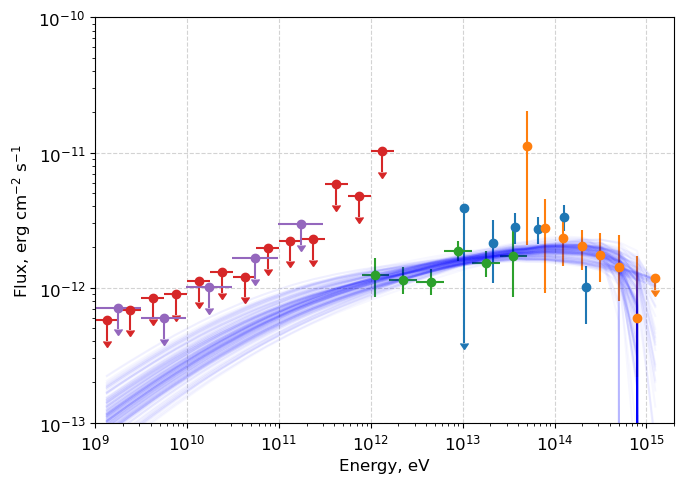

In [33]:
for i, name in enumerate(names):
    plt.errorbar(e[i], f_cor[i], xerr=[e_l[i], e_p[i]], yerr=[f_l_cor[i], f_p_cor[i]],
                 fmt='o', linestyle='None', uplims=f_p_cor[i] <= 0,
                 color=Tab10[i], label=f' ')

for res in result_mod2[::4]:
    plt.plot(synch.photon_energy, synch.model(res), alpha=.03, color='blue')

plt.xscale('log')
plt.xlim(1e9, 2e15)
plt.xlabel("Energy, eV")

plt.yscale('log')
plt.ylim(1e-13, 1e-10)
plt.ylabel(r"Flux, $\mathrm{erg~cm^{-2}~s^{-1}}$")
plt.tight_layout()
save_figure("spectrum_with_an_electron_fit_mcmc")
plt.show()

In [34]:
print(np.mean(result_mod2, axis=0))
print(result_mod2[np.argmax(result_mod2[:, 2])])
print(np.max(result_mod2, axis=0))
print(np.min(result_mod2, axis=0))

[-2.07202034  1.90769459 -0.05753872  3.42510673]
[-1.90467635  1.95980219  2.99778998  3.85774044]
[-1.65914661  2.03652982  2.99778998  4.57722447]
[-2.92644559  1.71341694 -2.99453583  0.04920326]


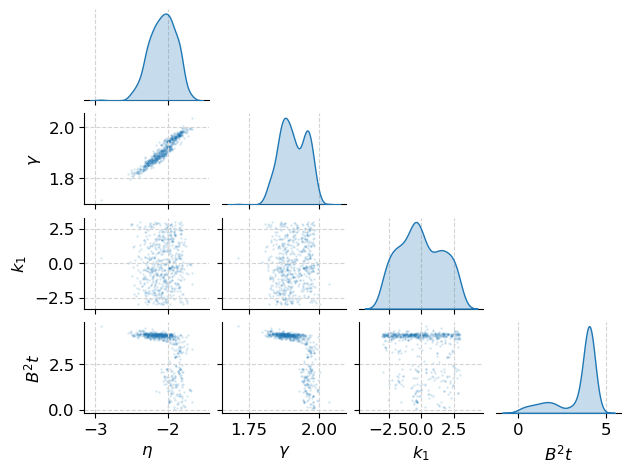

In [35]:
columns = [r"$\eta$", r"$\gamma$", r"$k_1$", r"$B^2t$"]
fs = pd.DataFrame(result_mod2, columns=columns)

g = sns.pairplot(fs, diag_kind="kde",
                plot_kws=dict(marker=".", linewidth=0, alpha=.2, s=10),
                corner=True, height=1.2, aspect=4/3)
# g.map_lower(sns.kdeplot, levels=5, color=".2", alpha=.3)
# save_figure(f"pairplot{nsteps}")
plt.show()

In [36]:
# XRISM ISOTROPIC AREA APPROXIMATION

amin_pc = 1/60 * 115 * u.pc / u.arcmin
XRISM_area = (629.4 * u.arcmin**2) * amin_pc**2

wl_ratio = 1/3.56
size_HESS = 110 * u.pc
energy_HESS = 40 * u.TeV
size_1TeV = size_HESS * (1 * u.TeV / energy_HESS)**(1/6)

print(size_1TeV)

e_volume = volume_approximation(synch.electron_energy, width_length_ratio=wl_ratio, size_1TeV=size_1TeV)
e_width  = width_approximation(synch.electron_energy, width_length_ratio=wl_ratio, size_1TeV=size_1TeV)
e_length = length_approximation(synch.electron_energy, size_1TeV=size_1TeV)

59.48160609161094 pc


In [37]:
bvalue = 4e-6

bfield = bvalue * Gauss
synch_photon_energy = np.logspace(-8, 15, 100) * u.eV
result_chosen = result_mod2


In [38]:
# SYNCHROTRON
bfield = 4e-6 * Gauss
bvalue = bfield.value

path = os.path.join(SYNCH_INTERP_DIR, f"synch_power_interp_{bvalue * 1e6:.1f}.pck")
synch_interp_data = pickle.load(open(path, "rb"))

synch_interp = synch_interp_data[2]

lg_ee = np.log10(synch.electron_energy.value)
lg_pe = np.log10(synch_photon_energy.value)
ee_pe, pe_ee = np.meshgrid(lg_ee, lg_pe, indexing='ij')
synch_table = 10**synch_interp((ee_pe, pe_ee)) * (1/u.s)

In [39]:
synch_flux_full = np.zeros([result_chosen.shape[0], synch_photon_energy.size]) * flux_unit

for i, res_i in enumerate(result_chosen):
    dN_dE = synch.cooled_spectrum(res_i)

    # Total synchrotron emission
    synch_lum_full = np.trapezoid(synch_table.T * dN_dE, synch.electron_energy, axis=1)
    synch_flux_full[i] = synch_lum_full * synch_photon_energy / synch.area

In [40]:
from spectrum.measurements_xray import constraint_Chandra, constraint_XRISM, weak_constraint_XRISM

In [2]:
plt.figure(figsize=(10, 6))

# UHE spectrum
data = pickle.load(open(os.path.join(SPECTRUM_DIR, "UHE_spectrum_corrected.pck"), "rb"))
names, e, f_cor, f_l_cor, f_p_cor, e_l, e_p = data
for i, name in enumerate(names):
    plt.errorbar(e[i], f_cor[i], xerr=[e_l[i], e_p[i]], yerr=[f_l_cor[i], f_p_cor[i]],
                 fmt='o', linestyle='None', uplims=f_p_cor[i] <= 0,
                 color=Tab10[i], label=f' ')

# X-Ray corrected
e, f, f_l, f_p, e_l, e_p = constraint_XRISM()
plt.errorbar(e, f, xerr=[e_l, e_p], yerr=[f_l, f_p],
             marker='o', markersize=3, label='XRISM, 2025', linestyle='None')
e, f, f_l, f_p, e_l, e_p = weak_constraint_XRISM()
plt.errorbar(e, f, xerr=[e_l, e_p], yerr=[f_l, f_p],
             marker='o', markersize=3, label='XRISM, 2025', linestyle='None')
e, f, f_l, f_p, e_l, e_p = constraint_Chandra()
plt.errorbar(e, f, xerr=[e_l, e_p], yerr=0.5 * f, uplims=True,
             marker='o', markersize=3, label='XRISM, 2025', linestyle='None', color='seagreen')

for i, res in enumerate(result_chosen):
    if res[-1] < 2.7:
        continue
    # plot gamma-ray spectrum
    plt.plot(synch.photon_energy, synch.model(res), alpha=.01, color='blue')
    plt.plot(synch_photon_energy, synch_flux_full[i], alpha=.01, color='blue')

plt.text(2e1, 5e-12, f'Full: {bvalue * 1e6:.1f} 'r'$\mathrm{\mu G}$', color='blue', rotation=35)
plt.text(2e1, 7e-13, f'D: {bvalue * 1e6:.1f} 'r'$\mathrm{\mu G}$', color='red', rotation=30)
plt.text(2e1, 1.5e-13, f'H: {bvalue * 1e6:.1f} 'r'$\mathrm{\mu G}$', color='green', rotation=25)
plt.text(5e10, 9e-14, 'Inverse Compton', color='blue', rotation=30)

plt.xscale('log')
plt.xlim(1e1, 2e15)
plt.xlabel("Energy, eV")

plt.yscale('log')
plt.ylim(1e-14, 1e-9)
plt.ylabel(r"Flux, $\mathrm{erg~cm^{-2}~s^{-1}}$")

plt.tight_layout()
# save_figure("electrons_single_flash_6uG")
plt.show()

NameError: name 'plt' is not defined